<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-14/RegressionCensus0604.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Random Forest | Digest Pickle [Fase 1 - Census Base]

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/census.pkl', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
random_census = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_census.fit(X_census_treinamento, Y_census_treinamento)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [10]:
previsores_random = random_census.predict(X_census_teste)
previsores_random

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Criando base Previsora

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
accuracy_score(Y_census_teste, previsores_random)

0.8390992835209826

In [13]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3419,  274],
       [ 512,  680]])

In [14]:
from yellowbrick.classifier import ConfusionMatrix

0.8390992835209826

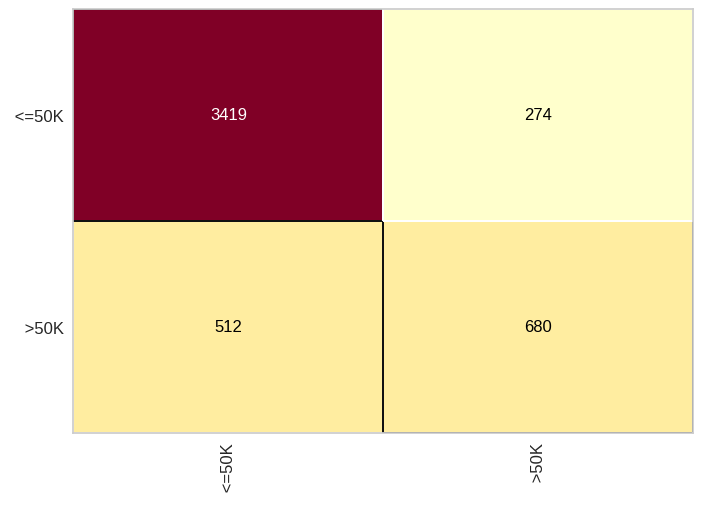

In [15]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [16]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.87      0.93      0.90      3693
        >50K       0.71      0.57      0.63      1192

    accuracy                           0.84      4885
   macro avg       0.79      0.75      0.77      4885
weighted avg       0.83      0.84      0.83      4885



# Pipeline Regressao | Digest [Fase 1 - Census Base]

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
regressao_census = LogisticRegression(random_state=1, max_iter=1000)
regressao_census.fit(X_census_treinamento, Y_census_treinamento)

LogisticRegression(max_iter=1000, random_state=1)

In [19]:
regression_previsores = regressao_census.predict(X_census_teste)
regression_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [20]:
accuracy_score(Y_census_teste, regression_previsores)

0.8497441146366428

0.8497441146366428

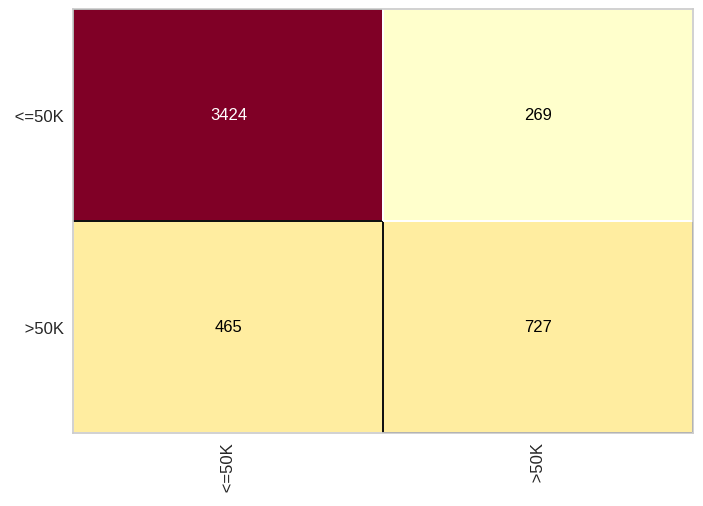

In [21]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(regressao_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)

In [22]:
print(classification_report(Y_census_teste, regression_previsores))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885

